# RandomForest — Feature Selection

**Method:** Permutation Importance with cross-validated stability analysis.

**Why permutation importance instead of impurity importance?**
- sklearn's `feature_importances_` (Gini/gain) is **biased toward correlated and high-cardinality features**
  (sklearn docs explicitly warn about this: "impurity-based importances can be misleading for high cardinality features")
- Permutation importance measures the actual drop in accuracy when a feature is shuffled — unbiased and model-agnostic
- Combined with stability analysis across CV folds, it identifies genuinely useful features

**Pipeline:**
1. **Decorrelation**: collapse redundant features (Spearman clustering, |ρ| > 0.7)
2. **Permutation importance**: on each CV fold, compute importance and select features with positive impact
3. **Stability analysis**: only keep features selected in ≥60% of folds

**Evaluation:** GroupKFold(n_splits=5) grouped by candle_id — no data leakage between candles.


In [1]:
import sys

from tqdm import tqdm

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json as _json
import random
import warnings
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from feature_utils import (
    decorrelate_features,
    feature_stability_report,
    plot_correlation_matrix,
    plot_stability,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")

RF_PARAMS = {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_leaf": 20,
    "random_state": 42,
    "n_jobs": -1,
}

## 1. Load data

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(_json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

print(f"Features: {len(all_feat_cols)}")
print(f"Candles: {df['candle_id'].nunique()}")
print(f"Rows: {len(df):,}")

Features: 60
Candles: 4565
Rows: 216,695


## 2. Stage 1: Decorrelation

Same as LR — collapse correlated features using Spearman clustering (|ρ| > 0.7).
See LR notebook for detailed explanation.


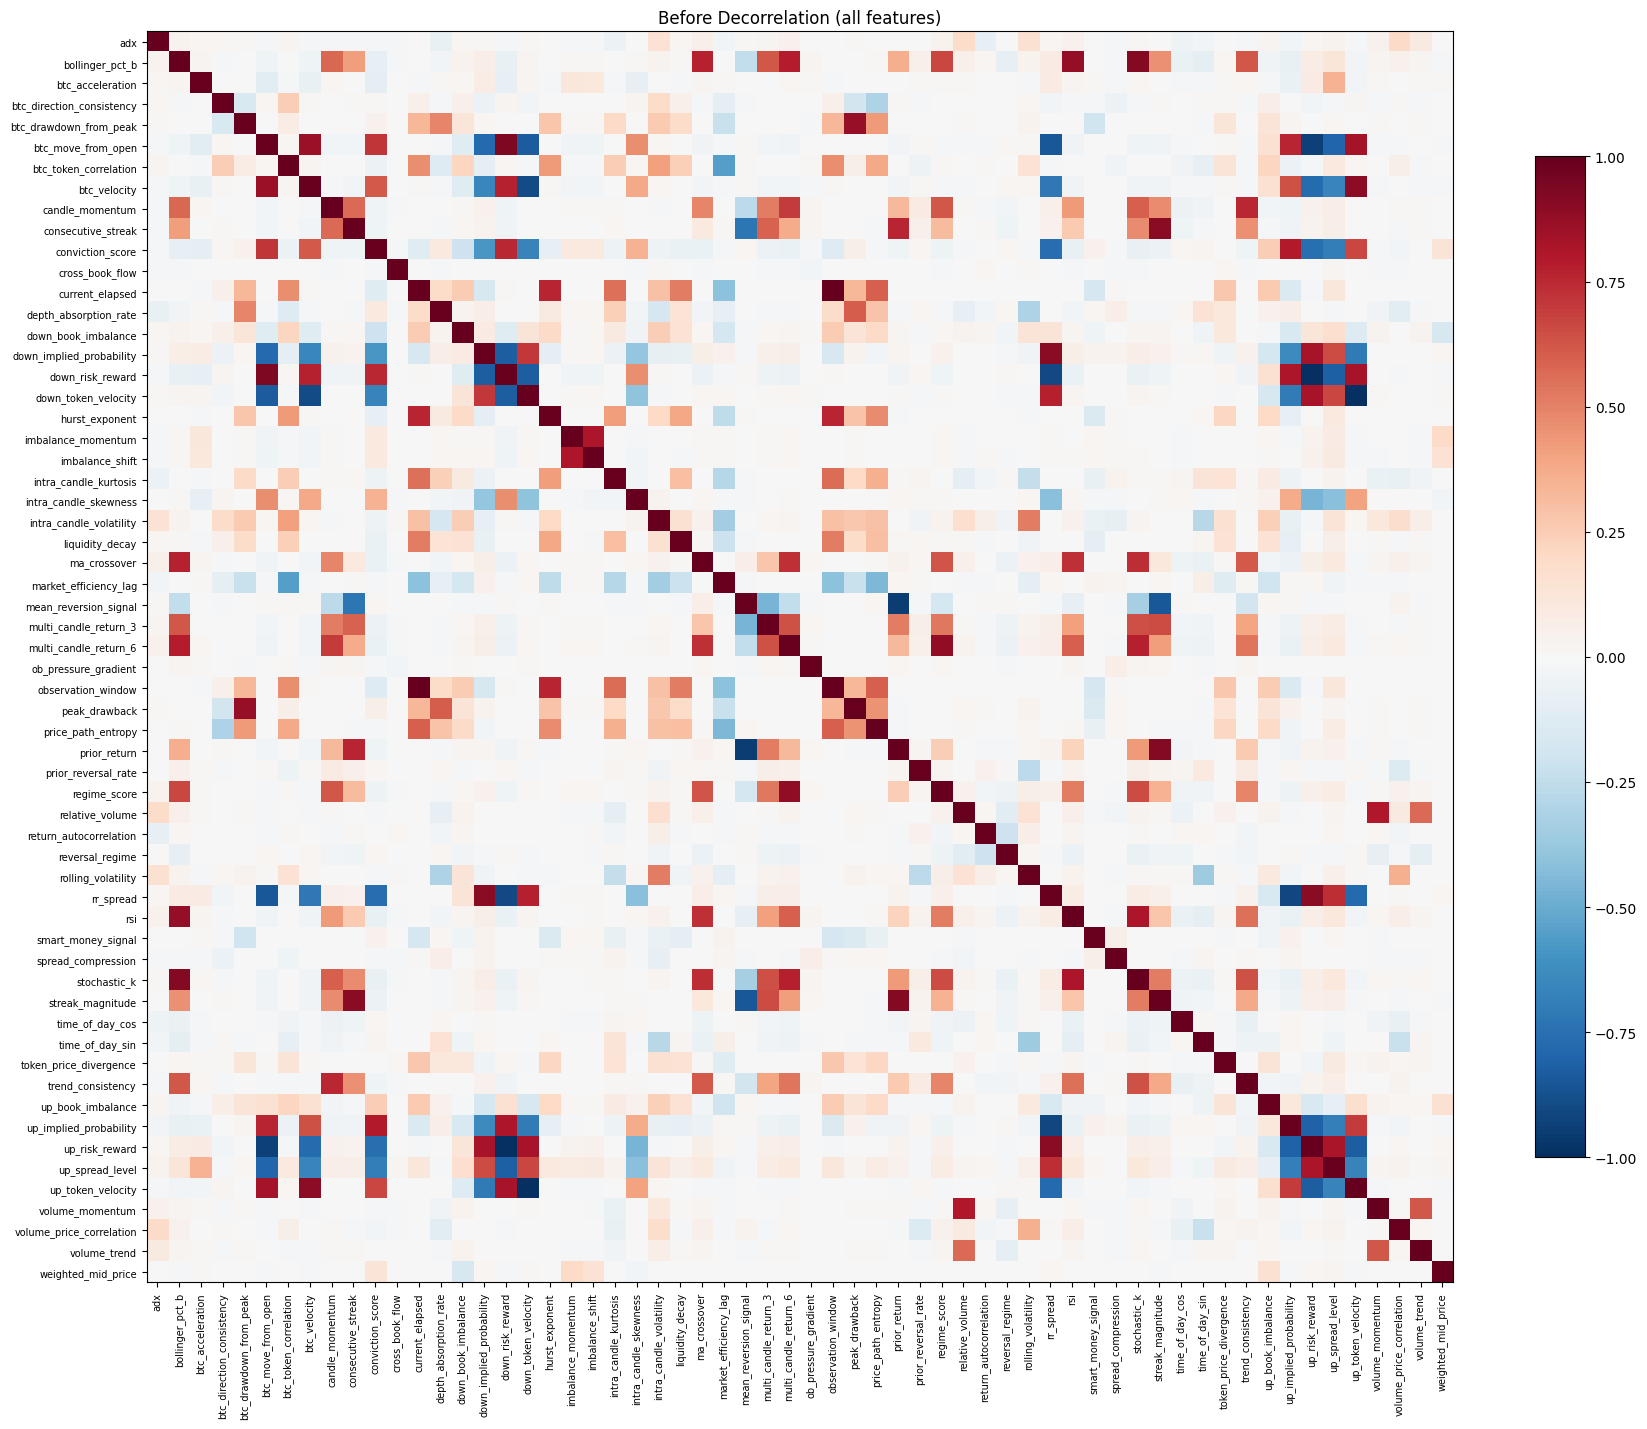


Before: 60 features
After:  37 features (23 dropped)

Clusters with >1 member:
  up_risk_reward (MI=0.2088) <- kept from 11 features
    dropped: ['btc_move_from_open', 'btc_velocity', 'conviction_score', 'down_implied_probability', 'down_risk_reward', 'down_token_velocity', 'rr_spread', 'up_implied_probability', 'up_spread_level', 'up_token_velocity']
  bollinger_pct_b (MI=0.6929) <- kept from 4 features
    dropped: ['ma_crossover', 'rsi', 'stochastic_k']
  streak_magnitude (MI=0.6929) <- kept from 4 features
    dropped: ['consecutive_streak', 'mean_reversion_signal', 'prior_return']
  hurst_exponent (MI=0.0002) <- kept from 3 features
    dropped: ['current_elapsed', 'observation_window']
  candle_momentum (MI=0.0090) <- kept from 2 features
    dropped: ['trend_consistency']
  multi_candle_return_6 (MI=0.6929) <- kept from 2 features
    dropped: ['regime_score']
  imbalance_momentum (MI=0.0389) <- kept from 2 features
    dropped: ['imbalance_shift']
  peak_drawback (MI=0.0037) 

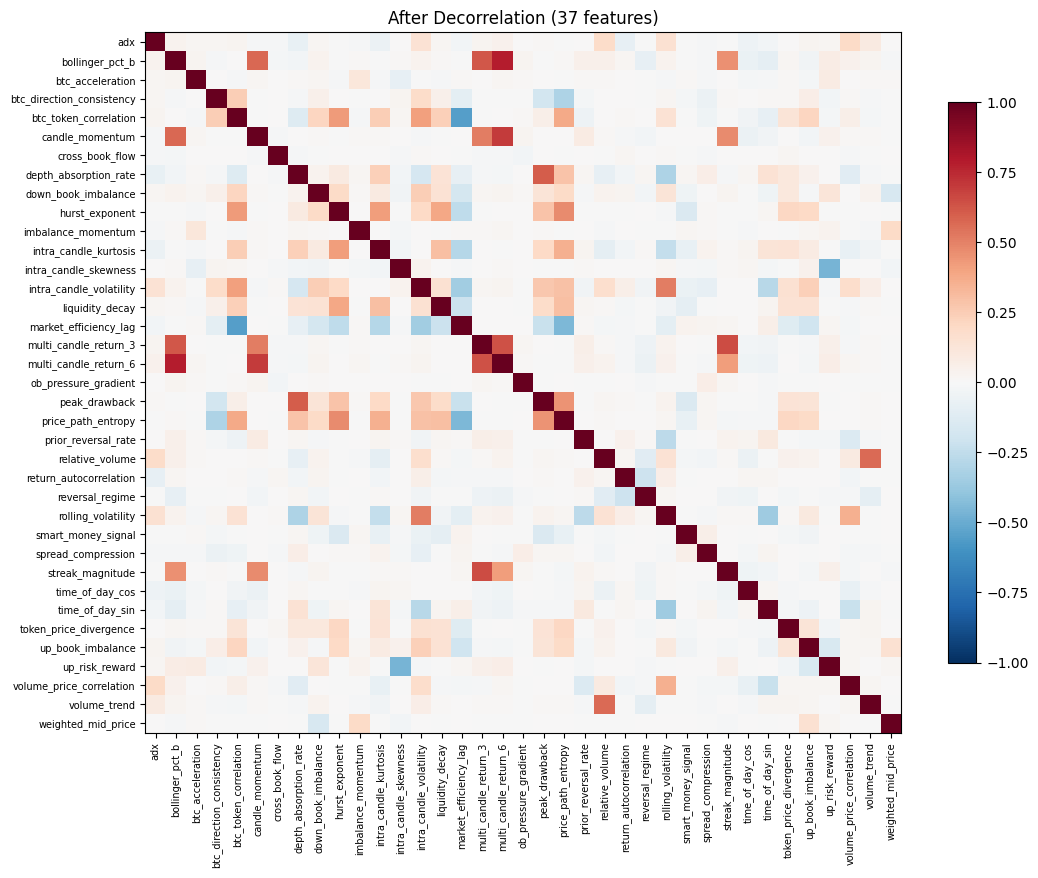

In [3]:
plot_correlation_matrix(df, all_feat_cols, "Before Decorrelation (all features)")

decorr_features, cluster_info = decorrelate_features(
    df,
    all_feat_cols,
    df["target"].values,
    threshold=0.7,
)

print(f"\nBefore: {len(all_feat_cols)} features")
print(f"After:  {len(decorr_features)} features ({len(all_feat_cols) - len(decorr_features)} dropped)")
print("\nClusters with >1 member:")
for feat, info in sorted(cluster_info.items(), key=lambda x: -x[1]["cluster_size"]):
    if info["cluster_size"] > 1:
        print(f"  {feat} (MI={info['mutual_info']:.4f}) <- kept from {info['cluster_size']} features")
        print(f"    dropped: {info['dropped']}")

plot_correlation_matrix(df, decorr_features, f"After Decorrelation ({len(decorr_features)} features)")

## 3. Stage 2: Permutation Importance with GroupKFold

**How permutation importance works:**
1. Train the model normally
2. For each feature: randomly shuffle that column's values, re-evaluate accuracy
3. The drop in accuracy = that feature's importance
4. If shuffling a feature doesn't hurt accuracy, it's not useful

**Why per-fold:** We compute permutation importance separately on each CV fold's validation set.
A feature must show positive importance in ≥60% of folds to be "stable."

This is fundamentally different from impurity importance:
- Impurity importance is computed during training (biased by what the tree happened to split on)
- Permutation importance is computed on held-out data (measures actual predictive value)


In [4]:
gkf = GroupKFold(n_splits=5)
groups = df["candle_id"].values
y = df["target"].values

fold_features = []
fold_accs = []
fold_f1s = []
fold_briers = []
all_importances = []

for fold_i, (train_idx, val_idx) in enumerate(tqdm(gkf.split(df, y, groups=groups), desc="CV folds")):
    print(f"--- Fold {fold_i + 1}/5 ---")
    X_train = df.iloc[train_idx][decorr_features].values
    X_val = df.iloc[val_idx][decorr_features].values
    y_train = df.iloc[train_idx]["target"].values
    y_val = df.iloc[val_idx]["target"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train, y_train)

    # Permutation importance on validation set
    perm_imp = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
    imp_mean = perm_imp.importances_mean
    all_importances.append(imp_mean)

    # Select features with positive permutation importance
    selected = [decorr_features[i] for i in range(len(decorr_features)) if imp_mean[i] > 0]
    fold_features.append(selected)

    # Evaluate on full feature set
    probs = rf.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)
    fold_accs.append(accuracy_score(y_val, preds))
    fold_f1s.append(f1_score(y_val, preds))
    fold_briers.append(brier_score_loss(y_val, probs))

    print(f"  Selected: {len(selected)} features, Acc: {fold_accs[-1] * 100:.1f}%")

print(f"\nMean CV accuracy (all decorr features): {np.mean(fold_accs) * 100:.1f}% +/- {np.std(fold_accs) * 100:.1f}%")

CV folds: 0it [00:00, ?it/s]

--- Fold 1/5 ---


/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

  Selected: 10 features, Acc: 74.0%
--- Fold 2/5 ---


/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

...

  Selected: 27 features, Acc: 75.5%
--- Fold 4/5 ---


/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

  Selected: 12 features, Acc: 74.0%
--- Fold 5/5 ---


/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/lfuryk/Documents/polymarket-bot/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

  Selected: 13 features, Acc: 75.3%

Mean CV accuracy (all decorr features): 74.5% +/- 0.7%


### Permutation importance visualization

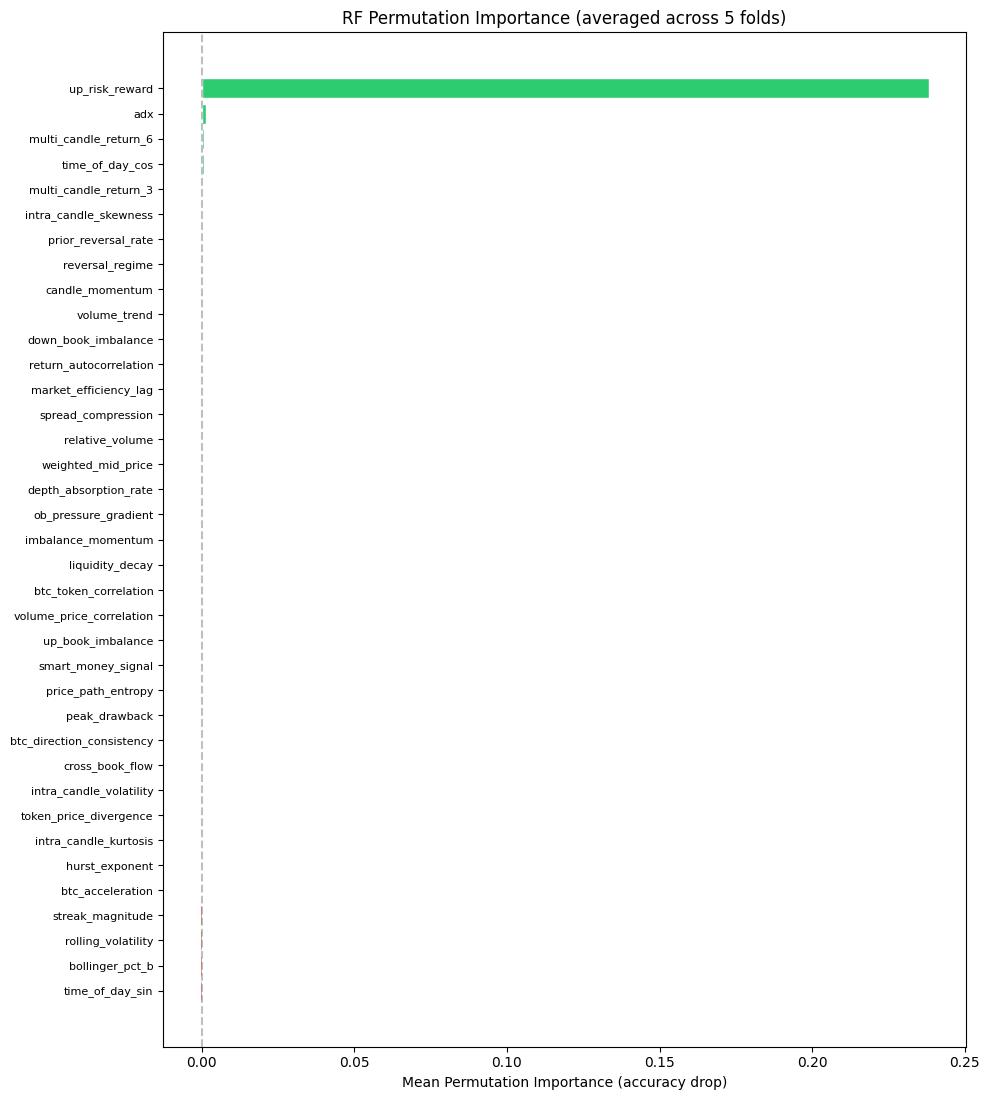

In [5]:
# Average importance across folds
avg_imp = np.mean(all_importances, axis=0)
sorted_idx = np.argsort(avg_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, max(6, len(decorr_features) * 0.3)))
names = [decorr_features[i] for i in sorted_idx]
values = [avg_imp[i] for i in sorted_idx]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in values]

ax.barh(range(len(names)), values, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Mean Permutation Importance (accuracy drop)")
ax.set_title("RF Permutation Importance (averaged across 5 folds)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Stage 3: Stability Analysis

A feature with positive permutation importance in only 1 fold is noise.
We keep features that are positively important in ≥60% of folds (at least 3 out of 5).


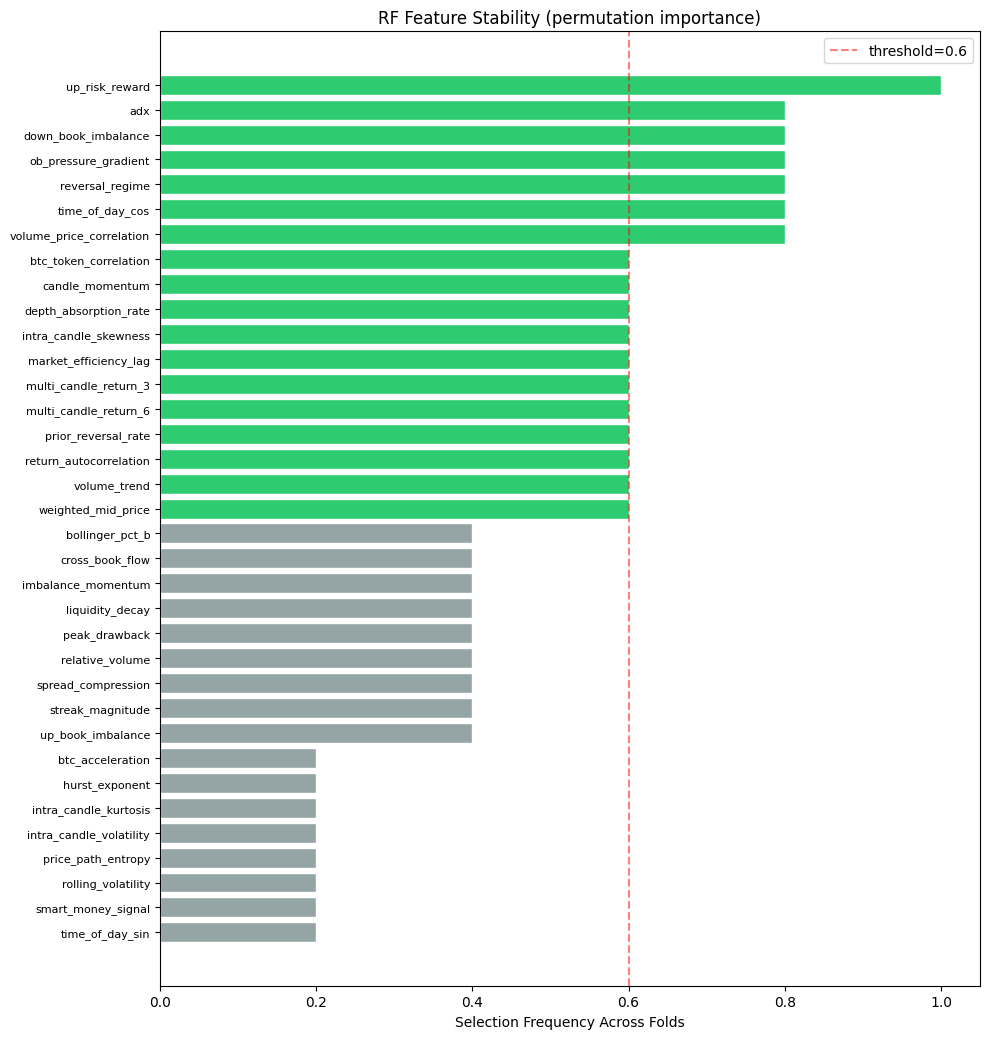


Stable features (positive importance in >=60% of folds): 18
  adx: 80%
  btc_token_correlation: 60%
  candle_momentum: 60%
  depth_absorption_rate: 60%
  down_book_imbalance: 80%
  intra_candle_skewness: 60%
  market_efficiency_lag: 60%
  multi_candle_return_3: 60%
  multi_candle_return_6: 60%
  ob_pressure_gradient: 80%
  prior_reversal_rate: 60%
  return_autocorrelation: 60%
  reversal_regime: 80%
  time_of_day_cos: 80%
  up_risk_reward: 100%
  volume_price_correlation: 80%
  volume_trend: 60%
  weighted_mid_price: 60%


In [6]:
stable_features, stability_scores = feature_stability_report(
    fold_features,
    decorr_features,
    threshold=0.6,
)

plot_stability(stability_scores, threshold=0.6, title="RF Feature Stability (permutation importance)")

print(f"\nStable features (positive importance in >=60% of folds): {len(stable_features)}")
for f in stable_features:
    print(f"  {f}: {stability_scores[f] * 100:.0f}%")

## 5. Final cross-validated evaluation with stable features only

In [7]:
accs, f1s, briers = [], [], []

for train_idx, val_idx in gkf.split(df, y, groups=groups):
    X_train = df.iloc[train_idx][stable_features].values
    X_val = df.iloc[val_idx][stable_features].values
    y_train = df.iloc[train_idx]["target"].values
    y_val = df.iloc[val_idx]["target"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_train, y_train)
    probs = rf.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)

    accs.append(accuracy_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))
    briers.append(brier_score_loss(y_val, probs))

print(f"Final CV results with {len(stable_features)} stable features:")
print(f"  Accuracy: {np.mean(accs) * 100:.1f}% +/- {np.std(accs) * 100:.1f}%")
print(f"  F1:       {np.mean(f1s) * 100:.1f}% +/- {np.std(f1s) * 100:.1f}%")
print(f"  Brier:    {np.mean(briers):.4f} +/- {np.std(briers):.4f}")

Final CV results with 18 stable features:
  Accuracy: 74.4% +/- 0.6%
  F1:       75.2% +/- 1.2%
  Brier:    0.1672 +/- 0.0029


## 6. Save config

In [8]:
config = {
    "model": "random_forest",
    "features": stable_features,
    "n_features": len(stable_features),
    "accuracy_cv_mean": round(float(np.mean(accs)), 4),
    "accuracy_cv_std": round(float(np.std(accs)), 4),
    "f1_cv_mean": round(float(np.mean(f1s)), 4),
    "brier_cv_mean": round(float(np.mean(briers)), 4),
    "selection_method": "permutation_importance_stability",
    "cv_folds": 5,
    "stability_threshold": 0.6,
    "feature_stability": {f: round(stability_scores[f], 2) for f in stable_features},
    "decorrelation_threshold": 0.7,
    "features_before_decorrelation": len(all_feat_cols),
    "features_after_decorrelation": len(decorr_features),
    "hyperparameters": {k: v for k, v in RF_PARAMS.items() if k != "n_jobs"},
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_rf.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} RF features to {out_path}")
print(f"Features: {config['features']}")

Saved 18 RF features to ../../data/optimal_features_rf.json
Features: ['adx', 'btc_token_correlation', 'candle_momentum', 'depth_absorption_rate', 'down_book_imbalance', 'intra_candle_skewness', 'market_efficiency_lag', 'multi_candle_return_3', 'multi_candle_return_6', 'ob_pressure_gradient', 'prior_reversal_rate', 'return_autocorrelation', 'reversal_regime', 'time_of_day_cos', 'up_risk_reward', 'volume_price_correlation', 'volume_trend', 'weighted_mid_price']


## Conclusion

Feature selection pipeline:
1. **Decorrelation**: collapsed correlated features using Spearman clustering (|ρ| > 0.7)
2. **Permutation importance**: computed per fold on held-out validation data (unbiased)
3. **Stability**: kept features with positive importance in ≥60% of folds

This replaces the old impurity-based importance ranking which was biased by correlated features
and evaluated on a single train/val split.

Run `rf/02_export.ipynb` to export the model, then `rf/03_strategy.ipynb` for strategy discovery.
